In [1]:
import numpy as np 
import matplotlib.pyplot as plt 


In [2]:
# Load our data set
x_train = np.array([1.0, 2.0])   #features
y_train = np.array([300.0, 500.0])   #target value

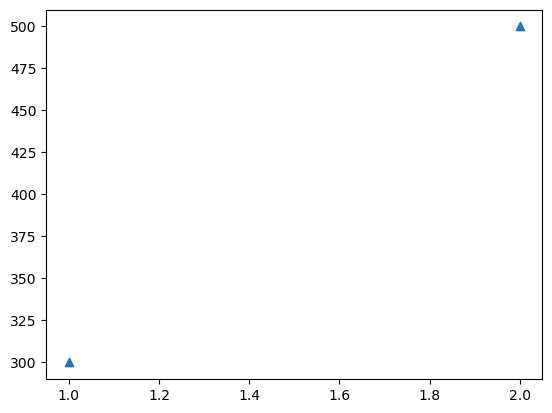

In [ ]:
plt.scatter(x_train,y_train,marker='^')

$$j(w,b)=1/2m*(w*x[i]+b - y[i])**2$$

In [14]:
def cost_function(w,b,x,y):
    m=x.shape[0]
    total_cost=0
    for i in range(m):
        fx_i = w*x[i] + b
        error_i = (fx_i - y[i])**2
        total_cost = total_cost + error_i
    total_cost = (1/(2*m))*total_cost
    return total_cost

In [17]:
w,b=199.9929,100.0116
jwb_x=cost_function(w,b,x_train,y_train)
print(jwb_x)

6.752500000054679e-06


NameError: name 'plt_gradients' is not defined

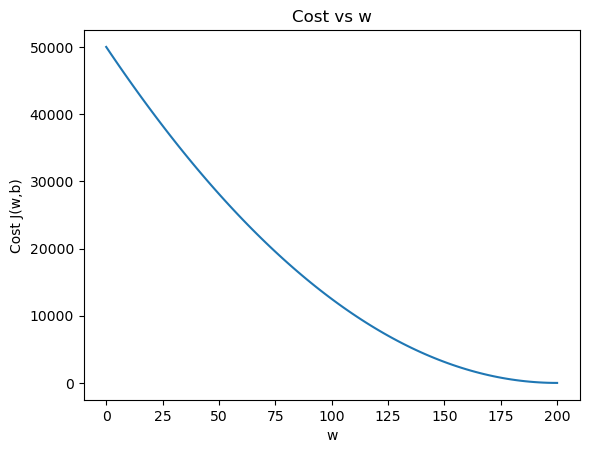

In [20]:

# Range of w values
w_values = np.linspace(0, 200, 100)

# Compute cost for each w
cost_values = []

for w in w_values:
    cost = cost_function(w, b, x_train, y_train)
    cost_values.append(cost)

# Plot
plt.figure()
plt.plot(w_values, cost_values)
plt.xlabel("w")
plt.ylabel("Cost J(w,b)")
plt.title("Cost vs w")
plt.show()

Text(0.5, 1.0, 'Best Fit Line')

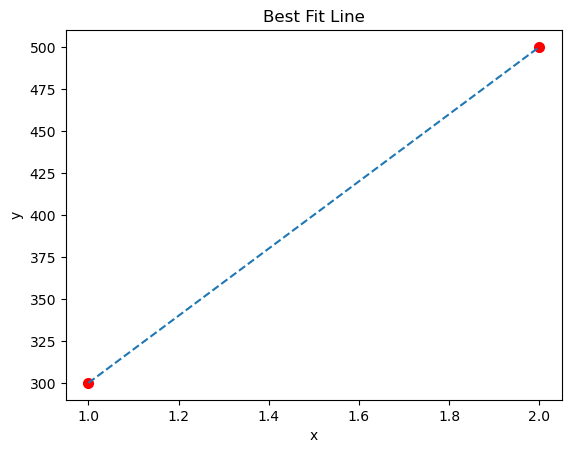

In [29]:
# Predictions
y_pred = w * x_train + b

# Plot,
plt.figure()

# Scatter plot (actual data)
plt.scatter(x_train, y_train,c='red',linewidth=2)

# Line plot (model prediction)
plt.plot(x_train, y_pred,ls='--')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Best Fit Line")

# derivate of cost function(w,b)

In [30]:
def derivate_gradint_function(w,b,x,y):
    m=x.shape[0]
    dj_dw=0
    dj_db=0
    for i in range(m):
        fwb_i = w*x[i]+b
        dj_dw_i = ((fwb_i - y[i])*x[i])
        dj_db_i = (fwb_i - y[i])
        dj_dw = dj_dw  + dj_dw_i
        dj_db = dj_db + dj_db_i
    dj_dw = (1/m)*dj_dw
    dj_db = (1/m)*dj_db
    return dj_dw,dj_db

In [ ]:
dj_dw,dj_db = derivate_gradint_function(50,20,x_train,y_train)


-495.0 -305.0


# gradient descent algo


In [40]:
def gradient_descent_function(w_in,b_in,x,y,alpha,itration,cost_function,derivate_gradint_function):
    w=w_in
    b=b_in
    count=0
    limit=itration/10
    J_history=[]
    P_history=[]
    for i in range(itration):
        dj_dw_i,dj_db_i = derivate_gradint_function(w,b,x,y)
        w = (w - (alpha * dj_dw_i))
        b = (b - (alpha * dj_db_i))
        
        if i < itration:
            J_history.append(cost_function(w,b,x,y))
            P_history.append([w,b])
        if count == limit:
            print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",
                  f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",
                  f"w: {w: 0.3e}, b:{b: 0.5e}")
            count=1
        count=count+1
    return w,b,J_history,P_history
 

In [41]:
w,b,J_history,P_history = gradient_descent_function(0,0,x_train,y_train,1.0e-2,10000,cost_function,derivate_gradint_function)
print(f"Final w , b: {w:8.4f},{b:8.4f}")

Iteration 1000: Cost 3.41e+00  dj_dw: -4.950e+02, dj_db: -3.050e+02   w:  1.949e+02, b: 1.08228e+02
Iteration 1999: Cost 7.94e-01  dj_dw: -4.950e+02, dj_db: -3.050e+02   w:  1.975e+02, b: 1.03969e+02
Iteration 2998: Cost 1.85e-01  dj_dw: -4.950e+02, dj_db: -3.050e+02   w:  1.988e+02, b: 1.01915e+02
Iteration 3997: Cost 4.30e-02  dj_dw: -4.950e+02, dj_db: -3.050e+02   w:  1.994e+02, b: 1.00924e+02
Iteration 4996: Cost 1.00e-02  dj_dw: -4.950e+02, dj_db: -3.050e+02   w:  1.997e+02, b: 1.00445e+02
Iteration 5995: Cost 2.33e-03  dj_dw: -4.950e+02, dj_db: -3.050e+02   w:  1.999e+02, b: 1.00215e+02
Iteration 6994: Cost 5.42e-04  dj_dw: -4.950e+02, dj_db: -3.050e+02   w:  1.999e+02, b: 1.00104e+02
Iteration 7993: Cost 1.26e-04  dj_dw: -4.950e+02, dj_db: -3.050e+02   w:  2.000e+02, b: 1.00050e+02
Iteration 8992: Cost 2.93e-05  dj_dw: -4.950e+02, dj_db: -3.050e+02   w:  2.000e+02, b: 1.00024e+02
Iteration 9991: Cost 6.82e-06  dj_dw: -4.950e+02, dj_db: -3.050e+02   w:  2.000e+02, b: 1.00012e+02


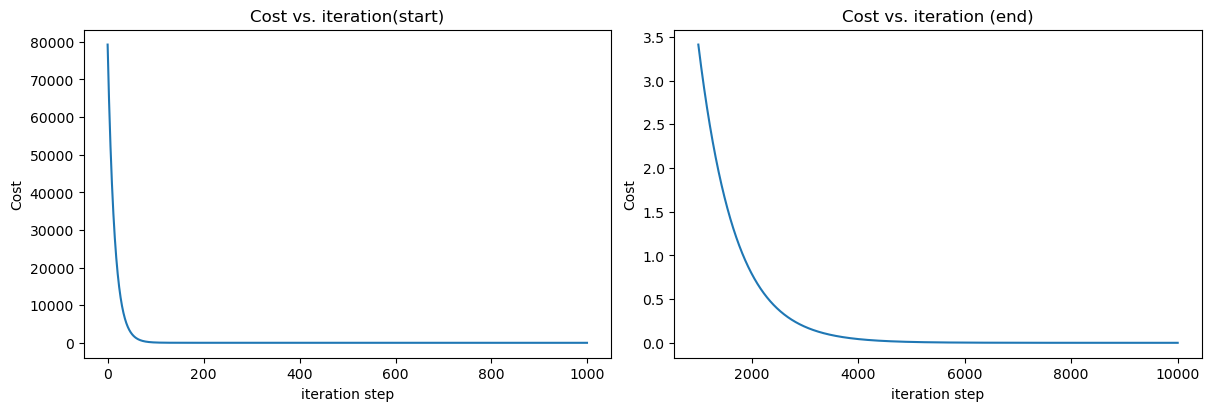

In [44]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(J_history[:1000])
ax2.plot(1000 + np.arange(len(J_history[1000:])), J_history[1000:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step') 
plt.show()

In [46]:
print(f"1000 sqft house prediction {w*1.0 + b:0.1f} Thousand dollars")
print(f"1200 sqft house prediction {w*1.2 + b:0.1f} Thousand dollars")
print(f"2000 sqft house prediction {w*2.0 + b:0.1f} Thousand dollars")

1000 sqft house prediction 300.0 Thousand dollars
1200 sqft house prediction 340.0 Thousand dollars
2000 sqft house prediction 500.0 Thousand dollars


NameError: name 'plt_contour_wgrad' is not defined

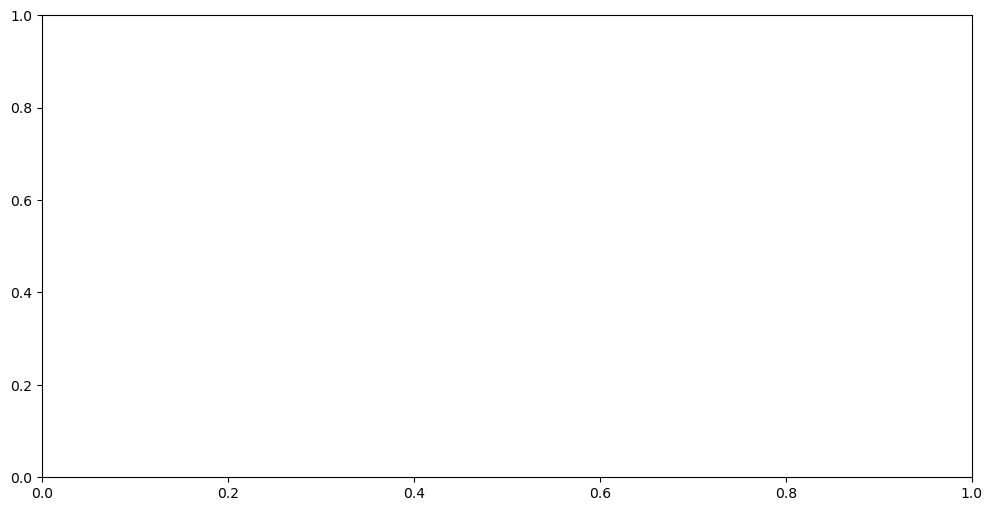

In [47]:
fig, ax = plt.subplots(1,1, figsize=(12, 6))
plt_contour_wgrad(x_train, y_train, p_hist, ax)

NameError: name 'gradient_descent' is not defined

In [52]:
w,b,J_history,P_history = gradient_descent_function(0,0,x_train,y_train,8.0e-1,1000,cost_function,derivate_gradint_function)
print(f"Final w , b: {w:8.4f},{b:8.4f}")

Iteration  100: Cost 4.01e+53  dj_dw: -4.950e+02, dj_db: -3.050e+02   w:  4.114e+26, b: 2.54277e+26
Iteration  199: Cost 2.05e+101  dj_dw: -4.950e+02, dj_db: -3.050e+02   w: -2.946e+50, b:-1.82057e+50
Iteration  298: Cost 1.05e+149  dj_dw: -4.950e+02, dj_db: -3.050e+02   w:  2.109e+74, b: 1.30349e+74
Iteration  397: Cost 5.40e+196  dj_dw: -4.950e+02, dj_db: -3.050e+02   w: -1.510e+98, b:-9.33271e+97
Iteration  496: Cost 2.77e+244  dj_dw: -4.950e+02, dj_db: -3.050e+02   w:  1.081e+122, b: 6.68202e+121
Iteration  595: Cost 1.42e+292  dj_dw: -4.950e+02, dj_db: -3.050e+02   w: -7.741e+145, b:-4.78418e+145
Iteration  694: Cost inf  dj_dw: -4.950e+02, dj_db: -3.050e+02   w:  5.542e+169, b: 3.42537e+169
Iteration  793: Cost inf  dj_dw: -4.950e+02, dj_db: -3.050e+02   w: -3.968e+193, b:-2.45249e+193
Iteration  892: Cost inf  dj_dw: -4.950e+02, dj_db: -3.050e+02   w:  2.841e+217, b: 1.75593e+217
Iteration  991: Cost inf  dj_dw: -4.950e+02, dj_db: -3.050e+02   w: -2.034e+241, b:-1.25721e+241
Fin

C:\Users\ASUS\AppData\Local\Temp\ipykernel_15468\3750283873.py:6: RuntimeWarning: overflow encountered in scalar power
  error_i = (fx_i - y[i])**2


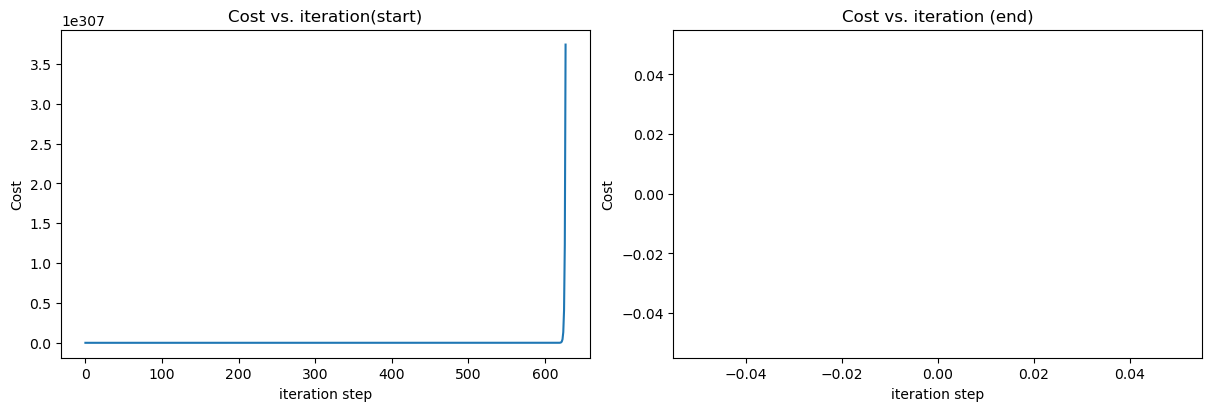

In [57]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(J_history[:1000])
ax2.plot(1000 + np.arange(len(J_history[1000:])), J_history[1000:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step') 
plt.show()